# Boruta-Shap feature selection for AqSolDB (RF + XGBoost)

Run from the `qspr` directory. If dependencies are missing, use uv:

```
uv venv .venv
uv pip install "numpy<2" "shap>=0.48" "numba>=0.57" xgboost==1.7.6   BorutaShap scikit-learn pandas scipy statsmodels matplotlib seaborn rdkit-pypi nbformat nbconvert ipykernel
```


In [1]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('AqSolDB_v1.0_min.csv')

In [3]:
def smiles_to_mol(s):
    try:
        return Chem.MolFromSmiles(str(s))
    except Exception as e:
        return None


df['mol'] = df['SMILES'].astype(str).map(smiles_to_mol)

[10:49:23] WARNING: not removing hydrogen atom without neighbors
[10:49:23] WARNING: not removing hydrogen atom without neighbors
[10:49:23] WARNING: not removing hydrogen atom without neighbors
[10:49:23] WARNING: not removing hydrogen atom without neighbors
[10:49:23] WARNING: not removing hydrogen atom without neighbors
[10:49:23] WARNING: not removing hydrogen atom without neighbors
[10:49:23] WARNING: not removing hydrogen atom without neighbors
[10:49:23] WARNING: not removing hydrogen atom without neighbors
[10:49:23] WARNING: not removing hydrogen atom without neighbors
[10:49:23] WARNING: not removing hydrogen atom without neighbors
[10:49:23] WARNING: not removing hydrogen atom without neighbors
[10:49:23] WARNING: not removing hydrogen atom without neighbors
[10:49:23] WARNING: not removing hydrogen atom without neighbors
[10:49:23] WARNING: not removing hydrogen atom without neighbors
[10:49:23] WARNING: not removing hydrogen atom without neighbors
[10:49:23] WARNING: not r

In [4]:
df

,ID,Name,InChIKey,SMILES,Solubility,mol
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,<rdkit.Chem.rdchem.Mol object at 0x1301dc120>
1,A-4,Benzo[cd]indol-2(1H)-one,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,<rdkit.Chem.rdchem.Mol object at 0x1301dc190>
2,A-5,4-chlorobenzaldehyde,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,<rdkit.Chem.rdchem.Mol object at 0x1301dc200>
3,A-8,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo...",XTUPUYCJWKHGSW-UHFFFAOYSA-L,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409,<rdkit.Chem.rdchem.Mol object at 0x1301dc270>
4,A-9,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,FAUAZXVRLVIARB-UHFFFAOYSA-N,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065,<rdkit.Chem.rdchem.Mol object at 0x1301dc2e0>
...,...,...,...,...,...,...
9977,I-84,tetracaine,GKCBAIGFKIBETG-UHFFFAOYSA-N,C(c1ccc(cc1)NCCCC)(=O)OCCN(C)C,-3.010000,<rdkit.Chem.rdchem.Mol object at 0x1302dae30>
9978,I-85,tetracycline,OFVLGDICTFRJMM-WESIUVDSSA-N,OC1=C(C(C2=C(O)[C@@](C(C(C(N)=O)=C(O)[C@H]3N(C...,-2.930000,<rdkit.Chem.rdchem.Mol object at 0x1302daea0>
9979,I-86,thymol,MGSRCZKZVOBKFT-UHFFFAOYSA-N,c1(cc(ccc1C(C)C)C)O,-2.190000,<rdkit.Chem.rdchem.Mol object at 0x1302daf10>
9980,I-93,verapamil,SGTNSNPWRIOYBX-UHFFFAOYSA-N,COc1ccc(CCN(C)CCCC(C#N)(C(C)C)c2ccc(OC)c(OC)c2...,-3.980000,<rdkit.Chem.rdchem.Mol object at 0x1302daf80>


In [5]:
RADIUS   = 2
N_BITS = 512
CHIRAL   = True

morganGenerator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=N_BITS)
def mol_to_ecfp(mol):
    if mol is None:
        return None
    global morganGenerator
    return morganGenerator.GetFingerprint(mol=mol)

df['ECFP'] = df['mol'].map(mol_to_ecfp)


In [6]:
df

,ID,Name,InChIKey,SMILES,Solubility,mol,ECFP
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,<rdkit.Chem.rdchem.Mol object at 0x1301dc120>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,A-4,Benzo[cd]indol-2(1H)-one,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,<rdkit.Chem.rdchem.Mol object at 0x1301dc190>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,A-5,4-chlorobenzaldehyde,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,<rdkit.Chem.rdchem.Mol object at 0x1301dc200>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,A-8,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo...",XTUPUYCJWKHGSW-UHFFFAOYSA-L,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409,<rdkit.Chem.rdchem.Mol object at 0x1301dc270>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,A-9,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,FAUAZXVRLVIARB-UHFFFAOYSA-N,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065,<rdkit.Chem.rdchem.Mol object at 0x1301dc2e0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...,...,...
9977,I-84,tetracaine,GKCBAIGFKIBETG-UHFFFAOYSA-N,C(c1ccc(cc1)NCCCC)(=O)OCCN(C)C,-3.010000,<rdkit.Chem.rdchem.Mol object at 0x1302dae30>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
9978,I-85,tetracycline,OFVLGDICTFRJMM-WESIUVDSSA-N,OC1=C(C(C2=C(O)[C@@](C(C(C(N)=O)=C(O)[C@H]3N(C...,-2.930000,<rdkit.Chem.rdchem.Mol object at 0x1302daea0>,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ..."
9979,I-86,thymol,MGSRCZKZVOBKFT-UHFFFAOYSA-N,c1(cc(ccc1C(C)C)C)O,-2.190000,<rdkit.Chem.rdchem.Mol object at 0x1302daf10>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
9980,I-93,verapamil,SGTNSNPWRIOYBX-UHFFFAOYSA-N,COc1ccc(CCN(C)CCCC(C#N)(C(C)C)c2ccc(OC)c(OC)c2...,-3.980000,<rdkit.Chem.rdchem.Mol object at 0x1302daf80>,"[1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."


In [7]:
df

,ID,Name,InChIKey,SMILES,Solubility,mol,ECFP
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,<rdkit.Chem.rdchem.Mol object at 0x1301dc120>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,A-4,Benzo[cd]indol-2(1H)-one,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,<rdkit.Chem.rdchem.Mol object at 0x1301dc190>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,A-5,4-chlorobenzaldehyde,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,<rdkit.Chem.rdchem.Mol object at 0x1301dc200>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,A-8,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo...",XTUPUYCJWKHGSW-UHFFFAOYSA-L,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409,<rdkit.Chem.rdchem.Mol object at 0x1301dc270>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,A-9,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,FAUAZXVRLVIARB-UHFFFAOYSA-N,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065,<rdkit.Chem.rdchem.Mol object at 0x1301dc2e0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...,...,...
9977,I-84,tetracaine,GKCBAIGFKIBETG-UHFFFAOYSA-N,C(c1ccc(cc1)NCCCC)(=O)OCCN(C)C,-3.010000,<rdkit.Chem.rdchem.Mol object at 0x1302dae30>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
9978,I-85,tetracycline,OFVLGDICTFRJMM-WESIUVDSSA-N,OC1=C(C(C2=C(O)[C@@](C(C(C(N)=O)=C(O)[C@H]3N(C...,-2.930000,<rdkit.Chem.rdchem.Mol object at 0x1302daea0>,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ..."
9979,I-86,thymol,MGSRCZKZVOBKFT-UHFFFAOYSA-N,c1(cc(ccc1C(C)C)C)O,-2.190000,<rdkit.Chem.rdchem.Mol object at 0x1302daf10>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
9980,I-93,verapamil,SGTNSNPWRIOYBX-UHFFFAOYSA-N,COc1ccc(CCN(C)CCCC(C#N)(C(C)C)c2ccc(OC)c(OC)c2...,-3.980000,<rdkit.Chem.rdchem.Mol object at 0x1302daf80>,"[1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."


In [8]:
from rdkit import DataStructs
df = df.dropna(subset=['ECFP', 'Solubility']).copy()

x = np.zeros((len(df), N_BITS), dtype=np.int8)
for i, fp in enumerate(df['ECFP']):
    arr = np.zeros((N_BITS,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    x[i] = arr
y = df['Solubility'].astype(float).to_numpy()

In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.30, random_state=42
)

In [10]:
x_train

array([[0, 1, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 1],
       [0, 1, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int8)

In [11]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    n_jobs=-1
)
rf.fit(x_train, y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
from sklearn.metrics import r2_score, mean_squared_error

pred = rf.predict(x_test)
r2 = r2_score(y_test, pred)
rmse = mean_squared_error(y_test, pred)

print(f"random forest (n={rf.n_estimators})")
print(f"R^2:  {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

random forest (n=500)
R^2:  0.636
RMSE: 1.977


In [13]:
rf.predict(x_test)

array([-6.13173891, -3.9703695 , -2.87209376, ..., -5.63464697,
       -2.34680914, -4.4121847 ])

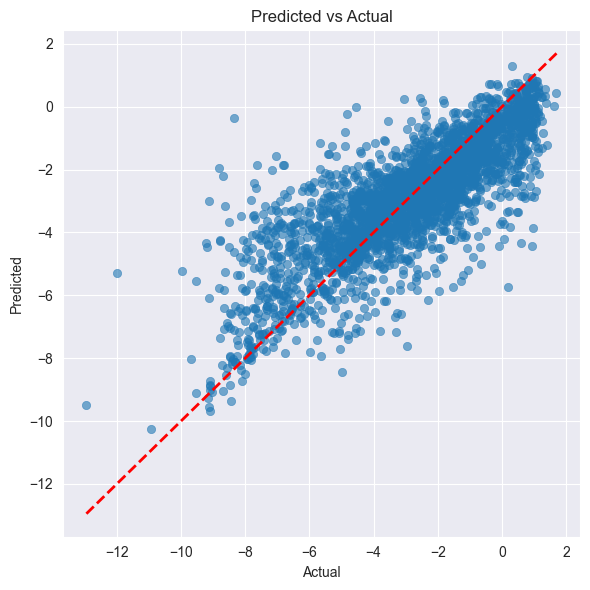

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# prediction vs actual
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=pred, alpha=0.6, edgecolor=None)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Predicted vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.show()

## Classification via cross-validation and ROC

In [15]:
# Use the median solubility to split the dataset into low/high solubility classes.
SOLUBILITY_THRESHOLD = df['Solubility'].median()
df['is_soluble'] = (df['Solubility'] >= SOLUBILITY_THRESHOLD).astype(int)

y_clf = df['is_soluble'].to_numpy()
class_counts = np.bincount(y_clf)
labels = ['low', 'high']
print(f"Solubility threshold (logS): {SOLUBILITY_THRESHOLD:.3f}")
print("Samples per class:", {labels[idx]: int(count) for idx, count in enumerate(class_counts)})


Solubility threshold (logS): -2.618
Samples per class: {'low': 4991, 'high': 4991}


In [16]:
# Stratified 10-fold cross-validation with a random forest classifier.
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
from sklearn.base import clone

rf_classifier = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced_subsample'
)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

fold_roc_curves = []
y_proba = np.zeros(len(y_clf), dtype=float)

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(x, y_clf), 1):
    model = clone(rf_classifier)
    model.fit(x[train_idx], y_clf[train_idx])
    fold_proba = model.predict_proba(x[test_idx])[:, 1]
    y_proba[test_idx] = fold_proba

    fpr, tpr, _ = roc_curve(y_clf[test_idx], fold_proba)
    fold_auc = roc_auc_score(y_clf[test_idx], fold_proba)
    fold_roc_curves.append((fold_idx, fpr, tpr, fold_auc))

y_pred = (y_proba >= 0.5).astype(int)

acc = accuracy_score(y_clf, y_pred)
roc_auc = roc_auc_score(y_clf, y_proba)

print(f"{cv.get_n_splits()}-fold stratified CV with RandomForestClassifier")
print(f"Accuracy : {acc:.3f}")
print(f"ROC AUC  : {roc_auc:.3f}")
print()
print(classification_report(y_clf, y_pred, target_names=['low_solubility', 'high_solubility']))



10-fold stratified CV with RandomForestClassifier
Accuracy : 0.824
ROC AUC  : 0.903

                 precision    recall  f1-score   support

 low_solubility       0.83      0.82      0.82      4991
high_solubility       0.82      0.83      0.82      4991

       accuracy                           0.82      9982
      macro avg       0.82      0.82      0.82      9982
   weighted avg       0.82      0.82      0.82      9982



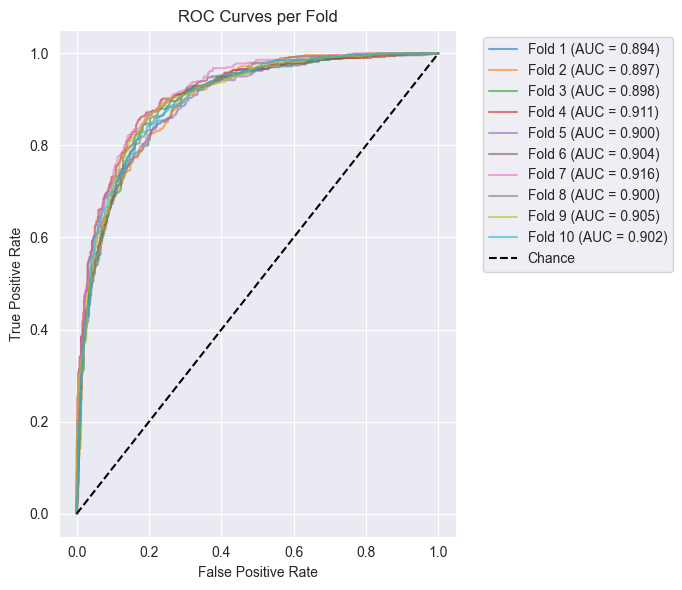

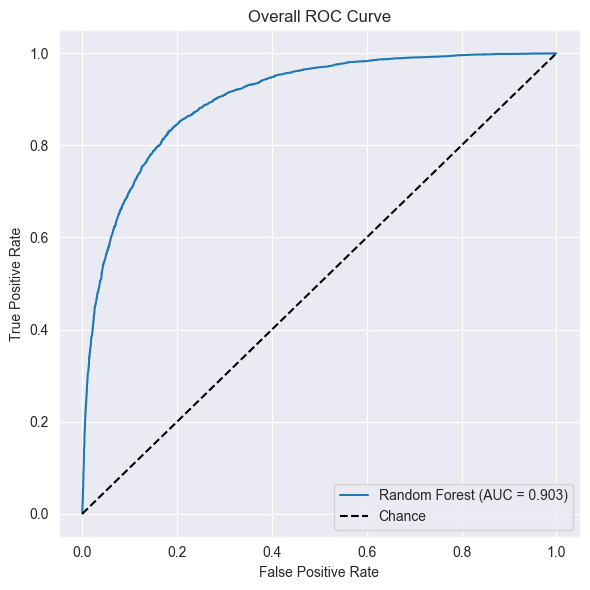

In [17]:
# Plot fold-wise ROC curves together with the overall ROC curve.
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
for fold_idx, fpr, tpr, fold_auc in fold_roc_curves:
    plt.plot(fpr, tpr, label=f'Fold {fold_idx} (AUC = {fold_auc:.3f})', alpha=0.6)
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves per Fold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

overall_fpr, overall_tpr, _ = roc_curve(y_clf, y_proba)

plt.figure(figsize=(6, 6))
plt.plot(overall_fpr, overall_tpr, label=f'Random Forest (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Overall ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()



In [18]:
# Estimate feature importance using Boruta-Shap and plot the ranked features.
import numpy as np
import scipy.stats as stats
from scipy.stats import binomtest

# Compatibility shims for newer numpy/scipy releases
if not hasattr(np, 'float'):
    np.float = float
if not hasattr(np, 'int'):
    np.int = int
if not hasattr(np, 'NaN'):
    np.NaN = np.nan

if not hasattr(stats, 'binom_test'):
    def _binom_test(k, n=None, p=0.5, alternative='two-sided'):
        k_clean = int(k)
        n_clean = int(n) if n is not None else None
        return binomtest(k=k_clean, n=n_clean, p=p, alternative=alternative).pvalue
    stats.binom_test = _binom_test

import shap
from BorutaShap import BorutaShap

# Patch BorutaShap.explain to handle SHAP output shape changes (n_samples, n_features, n_outputs)

def _patched_explain(self):
    explainer = shap.TreeExplainer(
        self.model,
        feature_perturbation="tree_path_dependent",
        approximate=True,
    )
    data = self.find_sample() if self.sample else self.X_boruta
    values = explainer.shap_values(data)
    arr = np.array(values)

    if isinstance(values, list):
        # list of class arrays
        arr = np.array(values)
        if arr.ndim == 3:
            arr = np.abs(arr).sum(axis=0).mean(0)
        else:
            arr = np.abs(arr).mean(0)
    elif arr.ndim == 3:
        # shap >= 0.48 returns (n_samples, n_features, n_outputs)
        if arr.shape[0] == data.shape[0] and arr.shape[1] == data.shape[1]:
            arr = np.abs(arr).mean(axis=0)
            if arr.ndim == 2:
                arr = arr.mean(axis=1)
        else:
            arr = np.abs(arr).sum(axis=0).mean(0)
    else:
        arr = np.abs(arr).mean(0)

    self.shap_values = arr


BorutaShap.explain = _patched_explain

feature_names = [f'bit_{i}' for i in range(x.shape[1])]
x_df = pd.DataFrame(x, columns=feature_names)

feature_selector = BorutaShap(
    model=RandomForestClassifier(
        n_estimators=200,
        max_depth=7,
        n_jobs=-1,
        random_state=42,
        class_weight='balanced_subsample'
    ),
    importance_measure='shap',
    classification=True
)


/Users/michael/dev/delta/qspr-explainability/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
feature_selector.fit(
    X=x_df,
    y=y_clf,
    n_trials=20,
    sample=False,
    train_or_test='train',
    normalize=True,
    verbose=True
)

rf_selected = feature_selector.Subset().columns.tolist()
print(f'RandomForest selected features: {len(rf_selected)}')


100%|██████████| 20/20 [02:59<00:00,  8.96s/it]

137 attributes confirmed important: ['bit_182', 'bit_64', 'bit_285', 'bit_392', 'bit_8', 'bit_147', 'bit_259', 'bit_203', 'bit_472', 'bit_18', 'bit_398', 'bit_185', 'bit_36', 'bit_175', 'bit_50', 'bit_268', 'bit_35', 'bit_356', 'bit_170', 'bit_282', 'bit_493', 'bit_16', 'bit_389', 'bit_56', 'bit_37', 'bit_225', 'bit_193', 'bit_420', 'bit_79', 'bit_81', 'bit_423', 'bit_393', 'bit_186', 'bit_295', 'bit_151', 'bit_453', 'bit_167', 'bit_119', 'bit_202', 'bit_301', 'bit_140', 'bit_129', 'bit_363', 'bit_462', 'bit_13', 'bit_319', 'bit_362', 'bit_15', 'bit_455', 'bit_66', 'bit_326', 'bit_211', 'bit_272', 'bit_242', 'bit_219', 'bit_95', 'bit_171', 'bit_456', 'bit_17', 'bit_324', 'bit_366', 'bit_434', 'bit_448', 'bit_154', 'bit_201', 'bit_63', 'bit_338', 'bit_204', 'bit_498', 'bit_412', 'bit_461', 'bit_86', 'bit_337', 'bit_128', 'bit_248', 'bit_33', 'bit_436', 'bit_80', 'bit_137', 'bit_280', 'bit_136', 'bit_492', 'bit_314', 'bit_452', 'bit_361', 'bit_507', 'bit_114', 'bit_145', 'bit_223', 'bit_

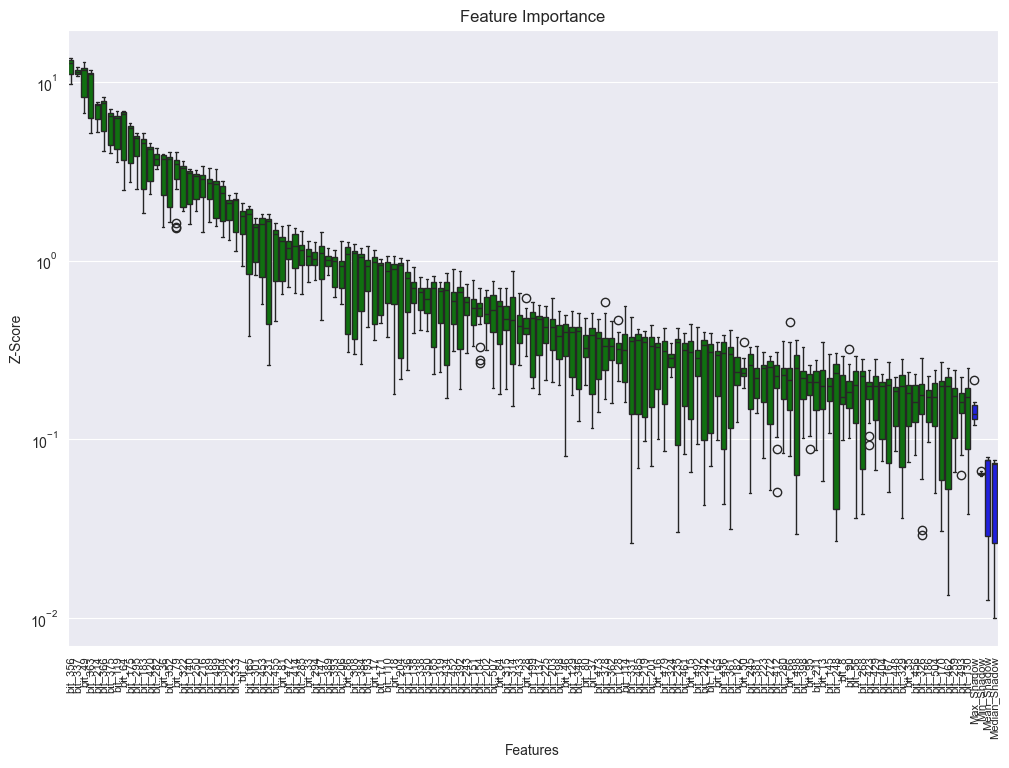

In [20]:

# Plot the ranked feature importances computed by Boruta-Shap.
feature_selector.plot(which_features='accepted')


## Boruta-Shap with XGBoost


In [21]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)

xgb_selector = BorutaShap(
    model=xgb_model,
    importance_measure='shap',
    classification=True
)

xgb_selector.fit(
    X=x_df,
    y=y_clf,
    n_trials=20,
    sample=False,
    train_or_test='train',
    normalize=True,
    verbose=True
)

xgb_selected = xgb_selector.Subset().columns.tolist()
print(f'XGBoost selected features: {len(xgb_selected)}')

overlap = sorted(set(rf_selected) & set(xgb_selected))
print(f'Overlap (RF ∩ XGB): {len(overlap)}')


100%|██████████| 20/20 [03:27<00:00, 10.37s/it]

37 attributes confirmed important: ['bit_119', 'bit_202', 'bit_285', 'bit_392', 'bit_147', 'bit_301', 'bit_140', 'bit_333', 'bit_204', 'bit_363', 'bit_138', 'bit_183', 'bit_337', 'bit_36', 'bit_116', 'bit_175', 'bit_33', 'bit_356', 'bit_282', 'bit_499', 'bit_322', 'bit_389', 'bit_492', 'bit_189', 'bit_366', 'bit_330', 'bit_114', 'bit_214', 'bit_49', 'bit_393', 'bit_295', 'bit_352', 'bit_4', 'bit_222', 'bit_375', 'bit_433', 'bit_250']
430 attributes confirmed unimportant: ['bit_357', 'bit_400', 'bit_64', 'bit_501', 'bit_478', 'bit_480', 'bit_88', 'bit_278', 'bit_44', 'bit_300', 'bit_61', 'bit_40', 'bit_371', 'bit_41', 'bit_160', 'bit_297', 'bit_279', 'bit_146', 'bit_471', 'bit_388', 'bit_227', 'bit_196', 'bit_368', 'bit_268', 'bit_511', 'bit_261', 'bit_390', 'bit_465', 'bit_457', 'bit_91', 'bit_16', 'bit_426', 'bit_269', 'bit_10', 'bit_225', 'bit_500', 'bit_73', 'bit_215', 'bit_267', 'bit_150', 'bit_383', 'bit_376', 'bit_339', 'bit_79', 'bit_81', 'bit_427', 'bit_141', 'bit_423', 'bit_46

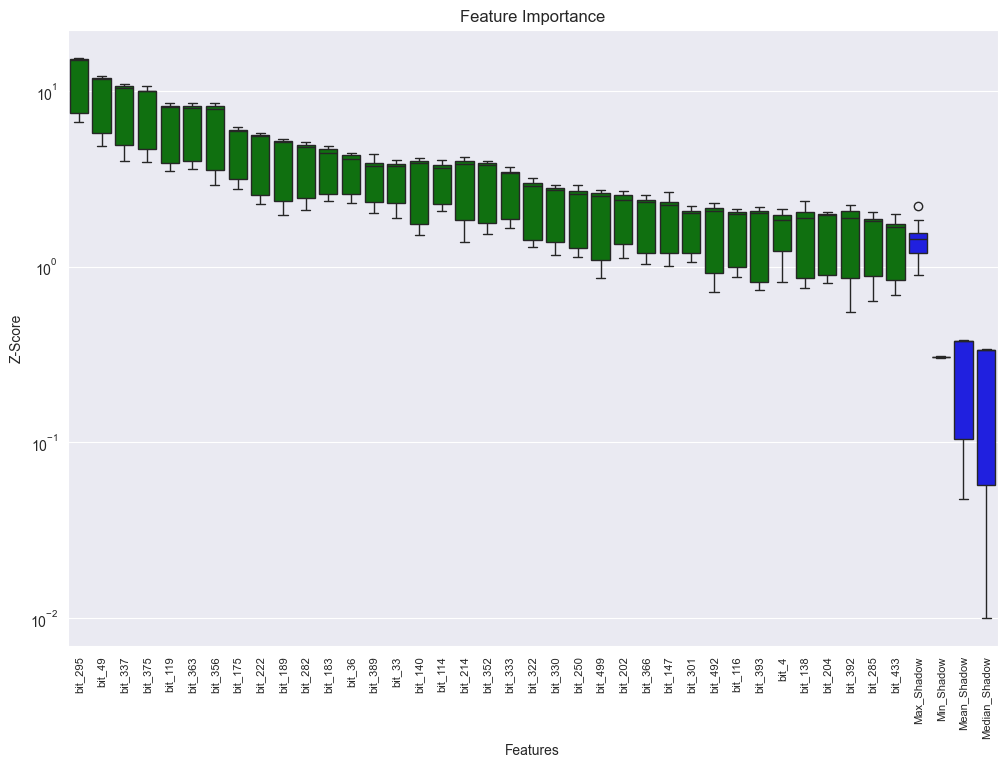

In [22]:
# Plot the ranked feature importances computed by Boruta-Shap for XGBoost.
xgb_selector.plot(which_features='accepted')
